# 🔬 MADELON Dataset — Unsupervised Learning Pipeline
### K-Means · Hierarchical Clustering · DBSCAN · PCA
---
| | |
|---|---|
| **Dataset** | MADELON (UCI ML Repository) |
| **Samples** | 2,600 (2,000 train + 600 validation) |
| **Features** | 500 numeric features |
| **Ground Truth** | Binary labels: +1 / -1 |
| **Algorithms** | K-Means, Hierarchical, DBSCAN |
| **Dimensionality Reduction** | PCA |
---

## 📦 Step 0 — Import Libraries

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 110

from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (silhouette_score, davies_bouldin_score,
                              calinski_harabasz_score,
                              adjusted_rand_score, normalized_mutual_info_score)
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage

print("✅ All libraries imported!")

✅ All libraries imported!


---
## 📂 Step 1 — Load Data

In [ ]:
# Load training and validation sets
X_train = pd.read_csv('MADELON/madelon_train.data', sep=' ', header=None).dropna(axis=1, how='all')
y_train = pd.read_csv('MADELON/madelon_train.labels', sep=' ', header=None)[0]
X_valid = pd.read_csv('MADELON/madelon_valid.data', sep=' ', header=None).dropna(axis=1, how='all')
y_valid = pd.read_csv('madelon_valid.labels', sep=' ', header=None)[0]

# Name features
X_train.columns = [f'f{i}' for i in range(X_train.shape[1])]
X_valid.columns = [f'f{i}' for i in range(X_valid.shape[1])]

# Combine for unsupervised learning (we use all available data)
X_all = pd.concat([X_train, X_valid], ignore_index=True)
y_all = pd.concat([y_train, y_valid], ignore_index=True)

print(f"Train shape   : {X_train.shape}")
print(f"Valid shape   : {X_valid.shape}")
print(f"Combined shape: {X_all.shape}")
print(f"Ground truth  : {y_all.unique()} (used only for external metrics)")

Train shape   : (2000, 500)
Valid shape   : (600, 500)
Combined shape: (2600, 500)
Ground truth  : [ 1 -1] (used only for external metrics)


---
## 📊 Step 2 — Exploratory Data Analysis (EDA)

### 2.1 — Basic Info & Missing Values

In [ ]:
print("=== Dataset Info ===")
print(f"Samples  : {X_all.shape[0]}")
print(f"Features : {X_all.shape[1]}")
print(f"Missing  : {X_all.isnull().sum().sum()}")
print(f"Feature range: min={X_all.min().min():.1f}, max={X_all.max().max():.1f}")
print()
print("=== Ground Truth Distribution ===")
print(y_all.value_counts())
print()
print("✅ No missing values — dataset is clean!")

=== Dataset Info ===
Samples  : 2600
Features : 500
Missing  : 0
Feature range: min=0.0, max=999.0

=== Ground Truth Distribution ===
 1    1300
-1    1300
Name: count, dtype: int64

✅ No missing values — dataset is clean!


### 2.2 — Class Distribution

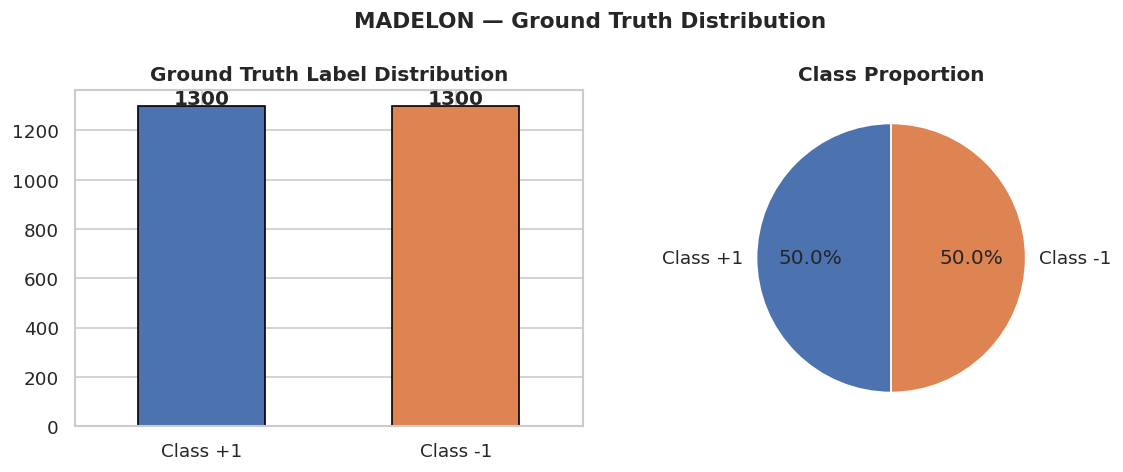

In [ ]:
class_counts = y_all.value_counts()
class_counts.index = ['Class +1', 'Class -1']

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
class_counts.plot(kind='bar', ax=axes[0], color=['#4C72B0','#DD8452'], edgecolor='black')
axes[0].set_title('Ground Truth Distribution', fontweight='bold')
axes[0].tick_params(axis='x', rotation=0)
for bar in axes[0].patches:
    axes[0].text(bar.get_x()+bar.get_width()/2, bar.get_height()+5,
                 int(bar.get_height()), ha='center', fontweight='bold')
axes[1].pie(class_counts, labels=class_counts.index, autopct='%1.1f%%',
            colors=['#4C72B0','#DD8452'], startangle=90)
axes[1].set_title('Class Proportion', fontweight='bold')
plt.suptitle('MADELON — Ground Truth Distribution', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 2.3 — Feature Variance Distribution

Max variance : 28503.99
Min variance : 0.0
Mean variance: 8441.32


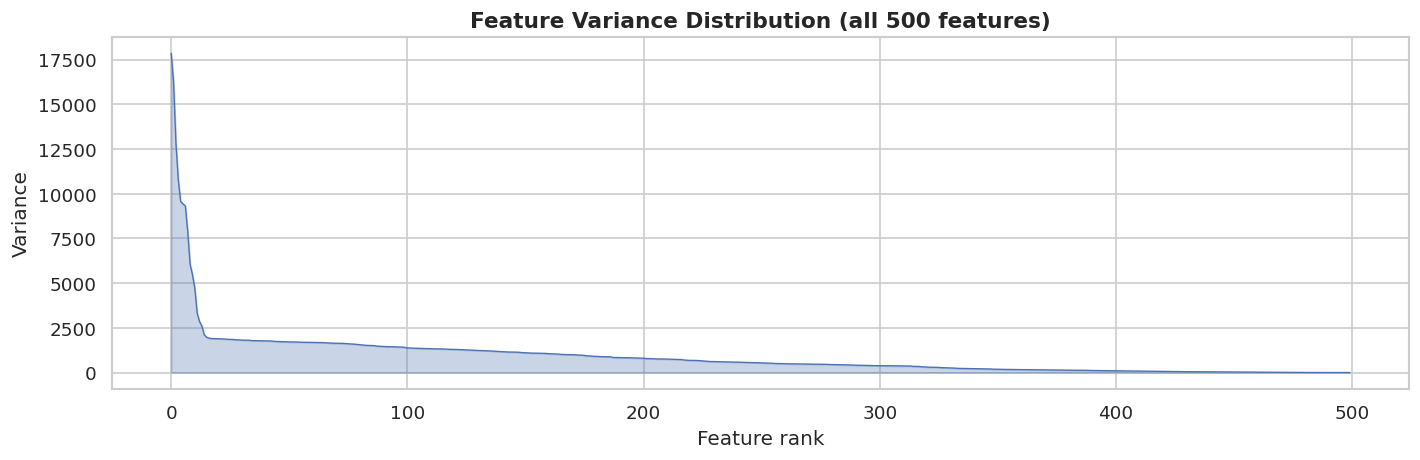

In [ ]:
variances = X_all.var().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(range(len(variances)), variances.values, color='#4C72B0', linewidth=0.8)
ax.fill_between(range(len(variances)), variances.values, alpha=0.3, color='#4C72B0')
ax.set_title('Feature Variance Distribution (all 500 features)', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature rank (sorted by variance)')
ax.set_ylabel('Variance')
plt.tight_layout()
plt.show()

print(f"Max variance : {variances.max():.2f}")
print(f"Min variance : {variances.min():.2f}")
print(f"Mean variance: {variances.mean():.2f}")

### 2.4 — Correlation Heatmap (Top 20 Features)

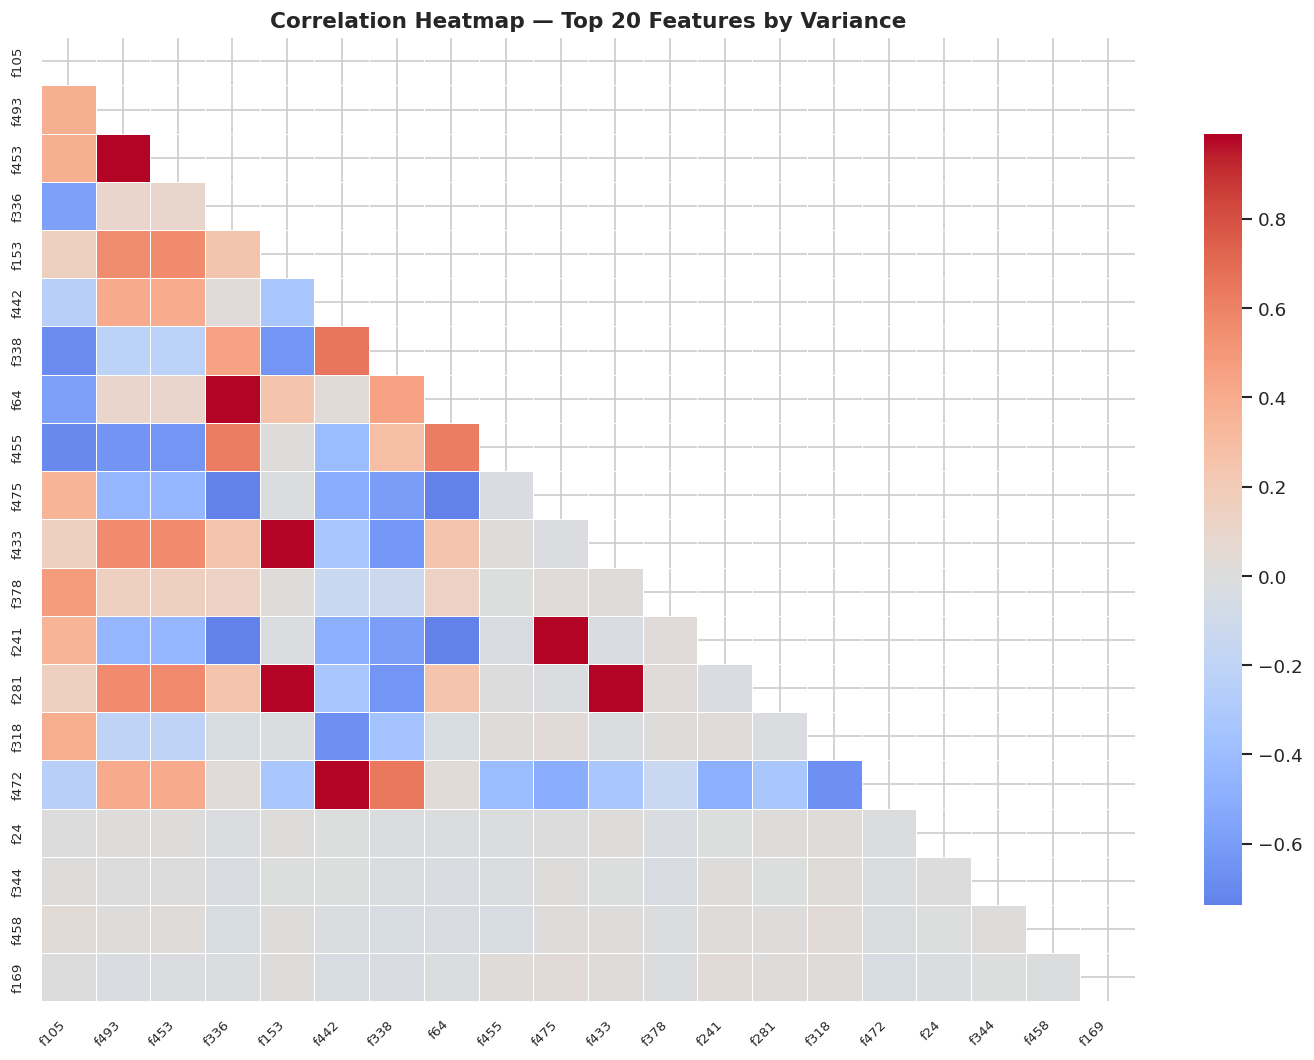

In [ ]:
top20 = variances.head(20).index.tolist()
corr = X_all[top20].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='coolwarm', center=0,
            linewidths=0.3, cbar_kws={'shrink':0.8}, ax=ax)
ax.set_title('Correlation Heatmap — Top 20 Features by Variance',
             fontsize=13, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
plt.show()

---
## 🔧 Step 3 — Preprocessing

### 3.1 — Scaling with StandardScaler

**Why scale?** MADELON features range from 0–999. Distance-based algorithms (K-Means, DBSCAN, Hierarchical) are sensitive to scale — a feature with large values would dominate the distance calculations unfairly. Scaling puts everything on equal footing (mean=0, std=1).

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_all)

print(f"Scaled shape : {X_scaled.shape}")
print(f"Mean (sample): {X_scaled[:, :5].mean(axis=0).round(4)}")
print(f"Std  (sample): {X_scaled[:, :5].std(axis=0).round(4)}")
print("✅ All features now have mean≈0 and std≈1")

Scaled shape : (2600, 500)
Mean (sample): [-0.  0. -0.  0.  0.]
Std  (sample): [1. 1. 1. 1. 1.]
✅ All features now have mean≈0 and std≈1


---
## 📐 Step 4 — PCA (Dimensionality Reduction)

**Why PCA?** 500 features is a lot. Many are redundant (MADELON has 480 noise features by design!). PCA finds the directions of maximum variance and compresses the data into fewer, more meaningful components.

We use PCA for two purposes:
- **Clustering:** Reduce to 50 components (capturing most variance) before running algorithms
- **Visualisation:** Reduce to 2 components to plot clusters

Components for 95% variance: 426
PC1 explains: 0.67%
PC2 explains: 0.60%


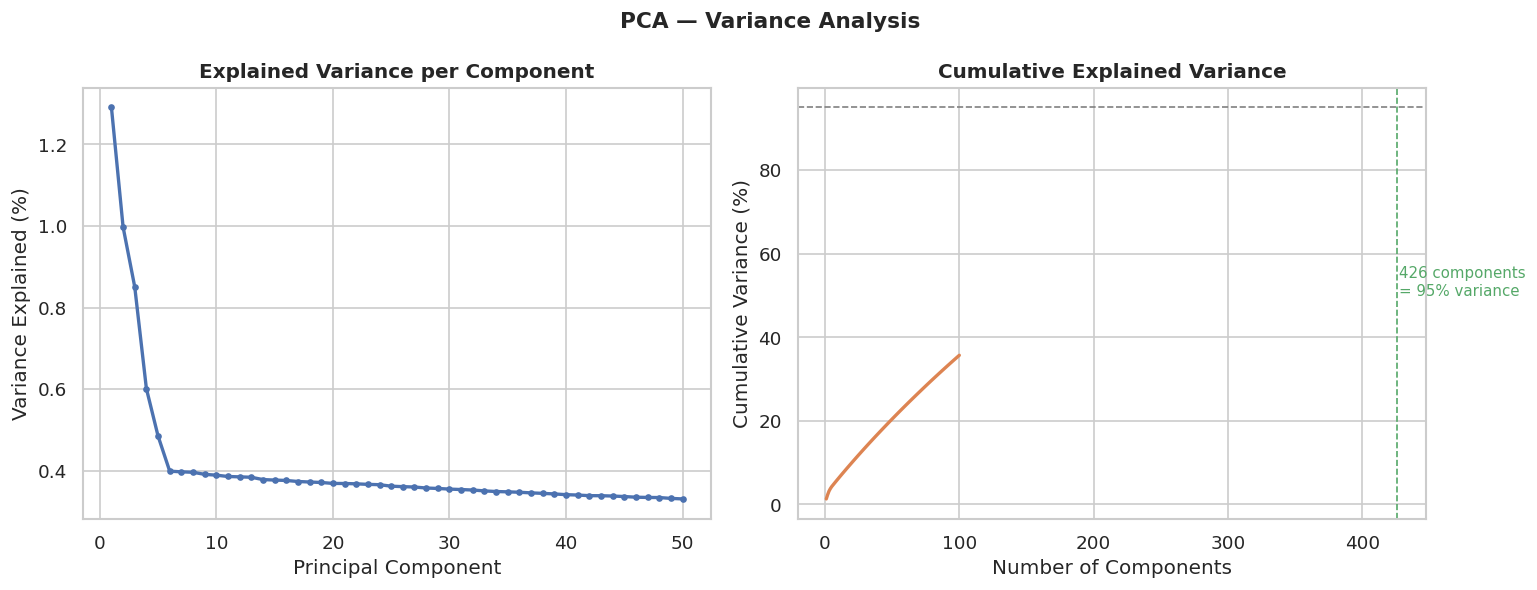

In [ ]:
# Fit PCA on all 500 features
pca_full = PCA(random_state=42)
pca_full.fit(X_scaled)

cumvar = np.cumsum(pca_full.explained_variance_ratio_)
n_95   = np.argmax(cumvar >= 0.95) + 1

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(range(1, 51), pca_full.explained_variance_ratio_[:50]*100,
             color='#4C72B0', linewidth=2, marker='o', markersize=3)
axes[0].set_title('Explained Variance per Component', fontweight='bold')
axes[0].set_xlabel('Principal Component')
axes[0].set_ylabel('Variance Explained (%)')

axes[1].plot(range(1, 101), cumvar[:100]*100, color='#DD8452', linewidth=2)
axes[1].axhline(95, color='grey', linestyle='--', linewidth=1)
axes[1].axvline(n_95, color='#55A868', linestyle='--', linewidth=1)
axes[1].text(n_95+1, 50, f'{n_95} components\n= 95% variance',
             color='#55A868', fontsize=9)
axes[1].set_title('Cumulative Explained Variance', fontweight='bold')
axes[1].set_xlabel('Number of Components')
axes[1].set_ylabel('Cumulative Variance (%)')

plt.suptitle('PCA — Variance Analysis', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Components for 95% variance: {n_95}")
print(f"PC1 explains: {pca_full.explained_variance_ratio_[0]*100:.2f}%")
print(f"PC2 explains: {pca_full.explained_variance_ratio_[1]*100:.2f}%")

In [ ]:
# PCA for clustering (50 components)
pca_n = PCA(n_components=50, random_state=42)
X_pca = pca_n.fit_transform(X_scaled)

# PCA for visualisation (2 components)
pca2 = PCA(n_components=2, random_state=42)
X_2d = pca2.fit_transform(X_scaled)

print(f"PCA for clustering : {X_pca.shape}")
print(f"PCA for visualisation: {X_2d.shape}")

PCA for clustering : (2600, 50)
PCA for visualisation: (2600, 2)


---
## 🎯 Step 5 — K-Means Clustering

**How K-Means works:** Randomly places K centroids, assigns each point to the nearest centroid, moves centroids to the mean of their points, repeats until stable.

**Hyperparameter to tune:** Number of clusters K → we use the **Elbow Method** and **Silhouette Score** to find the best K.

Best K by Silhouette: 2


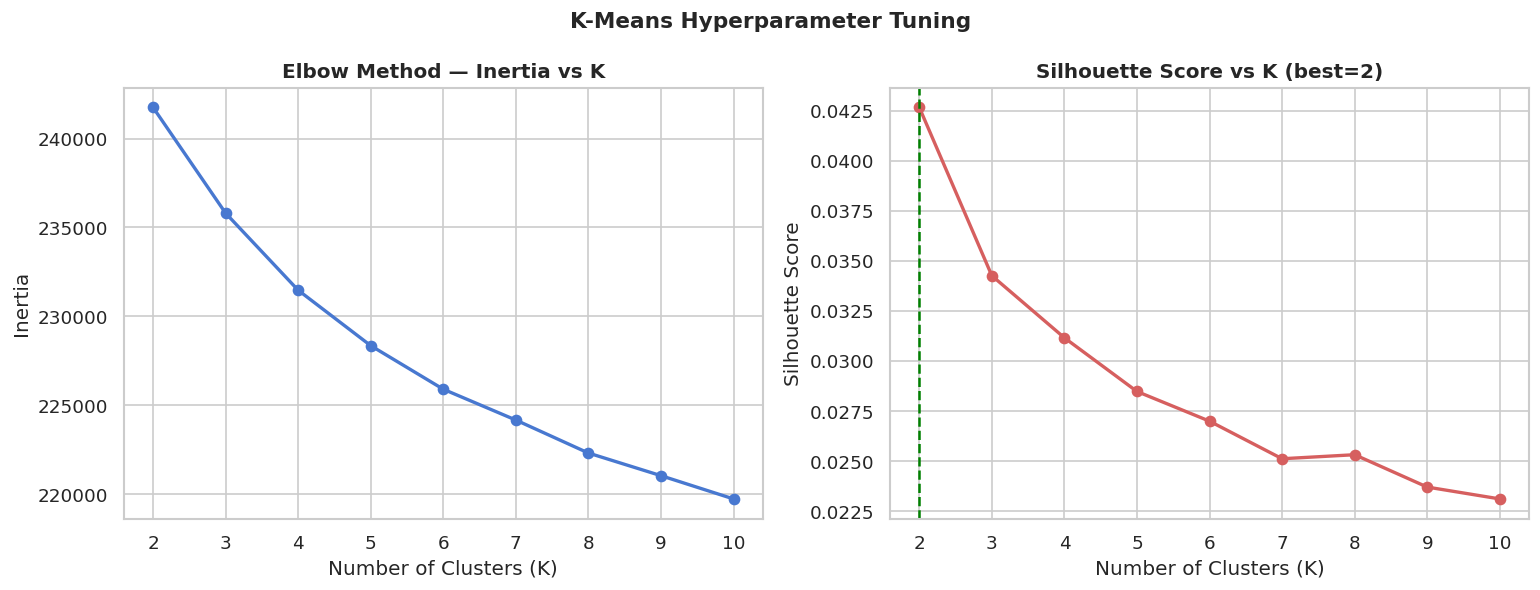

In [ ]:
# Hyperparameter tuning: find best K
inertias, silhouettes = [], []
K_range = range(2, 11)

for k in K_range:
    km = KMeans(n_clusters=k, init='k-means++', n_init=10, random_state=42)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].plot(K_range, inertias, 'bo-', linewidth=2, markersize=6)
axes[0].set_title('Elbow Method — Inertia vs K', fontweight='bold')
axes[0].set_xlabel('Number of Clusters (K)')
axes[0].set_ylabel('Inertia')

best_k = list(K_range)[np.argmax(silhouettes)]
axes[1].plot(K_range, silhouettes, 'ro-', linewidth=2, markersize=6)
axes[1].axvline(best_k, color='green', linestyle='--', linewidth=1.5)
axes[1].set_title(f'Silhouette Score vs K (best K={best_k})', fontweight='bold')
axes[1].set_xlabel('Number of Clusters (K)')
axes[1].set_ylabel('Silhouette Score')

plt.suptitle('K-Means Hyperparameter Tuning', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

print(f"Best K by Silhouette: {best_k}")

In [ ]:
# Train final K-Means with best K
km_final = KMeans(n_clusters=best_k, init='k-means++', n_init=10, random_state=42)
km_labels = km_final.fit_predict(X_pca)

# Metrics
km_sil = silhouette_score(X_pca, km_labels)
km_dbi = davies_bouldin_score(X_pca, km_labels)
km_chi = calinski_harabasz_score(X_pca, km_labels)
km_ari = adjusted_rand_score(y_all, km_labels)
km_nmi = normalized_mutual_info_score(y_all, km_labels)

print("=== K-Means Results ===")
print(f"Silhouette Score    : {km_sil:.4f}  (higher = better, max=1)")
print(f"Davies-Bouldin Index: {km_dbi:.4f}  (lower = better)")
print(f"Calinski-Harabasz  : {km_chi:.2f} (higher = better)")
print(f"Adjusted Rand Index : {km_ari:.4f}  (vs ground truth)")
print(f"Norm. Mutual Info  : {km_nmi:.4f}  (vs ground truth)")

=== K-Means Results ===
Silhouette Score    : 0.0427  (higher = better, max=1)
Davies-Bouldin Index: 4.6027  (lower = better)
Calinski-Harabasz  : 121.45 (higher = better)
Adjusted Rand Index : 0.0293  (vs ground truth)
Norm. Mutual Info  : 0.0215  (vs ground truth)


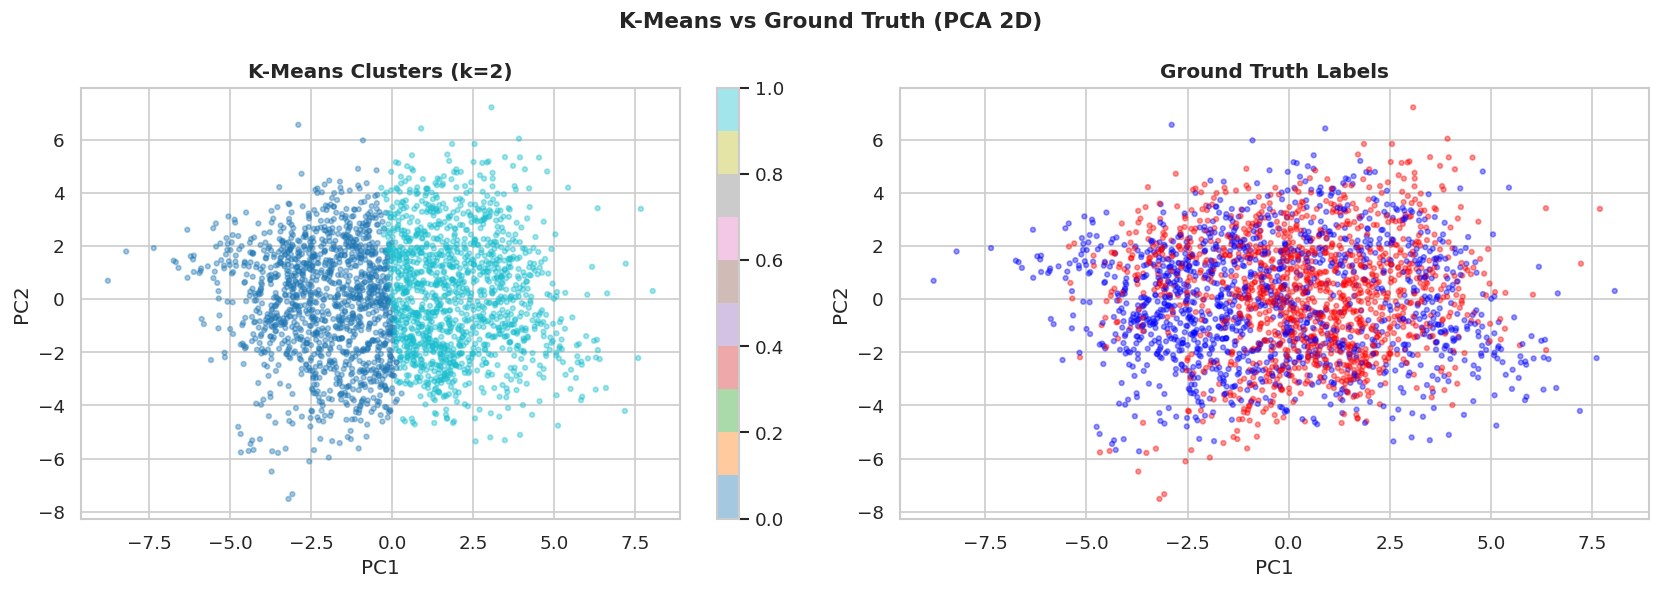

In [ ]:
# Visualise K-Means clusters in PCA 2D space
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
scatter = axes[0].scatter(X_2d[:,0], X_2d[:,1], c=km_labels,
                          cmap='tab10', alpha=0.4, s=8)
axes[0].set_title(f'K-Means Clusters (k={best_k})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
plt.colorbar(scatter, ax=axes[0])

axes[1].scatter(X_2d[:,0], X_2d[:,1], c=y_all.map({1:0,-1:1}),
                cmap='bwr', alpha=0.4, s=8)
axes[1].set_title('Ground Truth Labels', fontweight='bold')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2')

plt.suptitle('K-Means vs Ground Truth (PCA 2D)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🌳 Step 6 — Hierarchical Clustering

**How Hierarchical works:** Starts with each point as its own cluster, then merges the two closest clusters repeatedly until one cluster remains. We cut the tree at our desired number of clusters.

**Hyperparameters:** `n_clusters` and `linkage` (how distance between clusters is measured):
- **Ward:** minimises variance within clusters
- **Complete:** uses maximum distance between points
- **Average:** uses average distance between all points

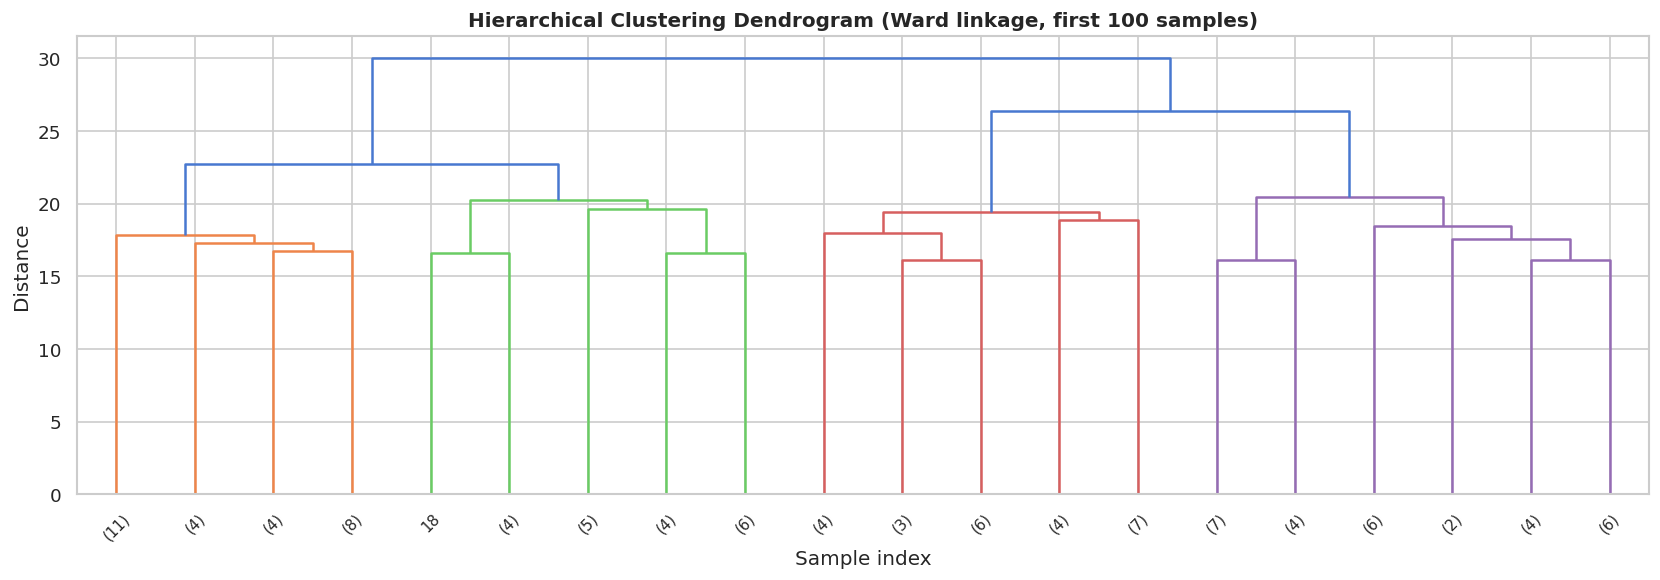

In [ ]:
# Dendrogram — visualise the merging process
from scipy.cluster.hierarchy import dendrogram, linkage

X_sub = X_pca[:100]   # subset for readability
Z = linkage(X_sub, method='ward')

fig, ax = plt.subplots(figsize=(14, 5))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=20,
           leaf_rotation=45, leaf_font_size=9)
ax.set_title('Dendrogram (Ward linkage, first 100 samples)', fontweight='bold')
ax.set_xlabel('Sample index'); ax.set_ylabel('Distance')
plt.tight_layout()
plt.show()

In [ ]:
# Try all three linkage methods
linkages = ['ward', 'complete', 'average']
hc_results = {}

for link in linkages:
    hc = AgglomerativeClustering(n_clusters=2, linkage=link)
    lbl = hc.fit_predict(X_pca)
    hc_results[link] = {
        'labels': lbl,
        'sil': silhouette_score(X_pca, lbl),
        'dbi': davies_bouldin_score(X_pca, lbl),
        'chi': calinski_harabasz_score(X_pca, lbl),
        'ari': adjusted_rand_score(y_all, lbl),
        'nmi': normalized_mutual_info_score(y_all, lbl)
    }

print("=== Hierarchical Clustering — Linkage Comparison ===")
print(f"{'Linkage':<12} {'Silhouette':>12} {'DBI':>8} {'ARI':>8}")
print("-" * 42)
for link in linkages:
    r = hc_results[link]
    print(f"{link:<12} {r['sil']:>12.4f} {r['dbi']:>8.4f} {r['ari']:>8.4f}")

best_link = max(hc_results, key=lambda x: hc_results[x]['sil'])
print(f"\n✅ Best linkage: {best_link}")

=== Hierarchical Clustering — Linkage Comparison ===
Linkage        Silhouette      DBI      ARI
------------------------------------------
ward               0.0265   5.7737   0.0060
complete           0.0224   6.3368   0.0030
average            0.1489   1.3666   0.0000

✅ Best linkage: average


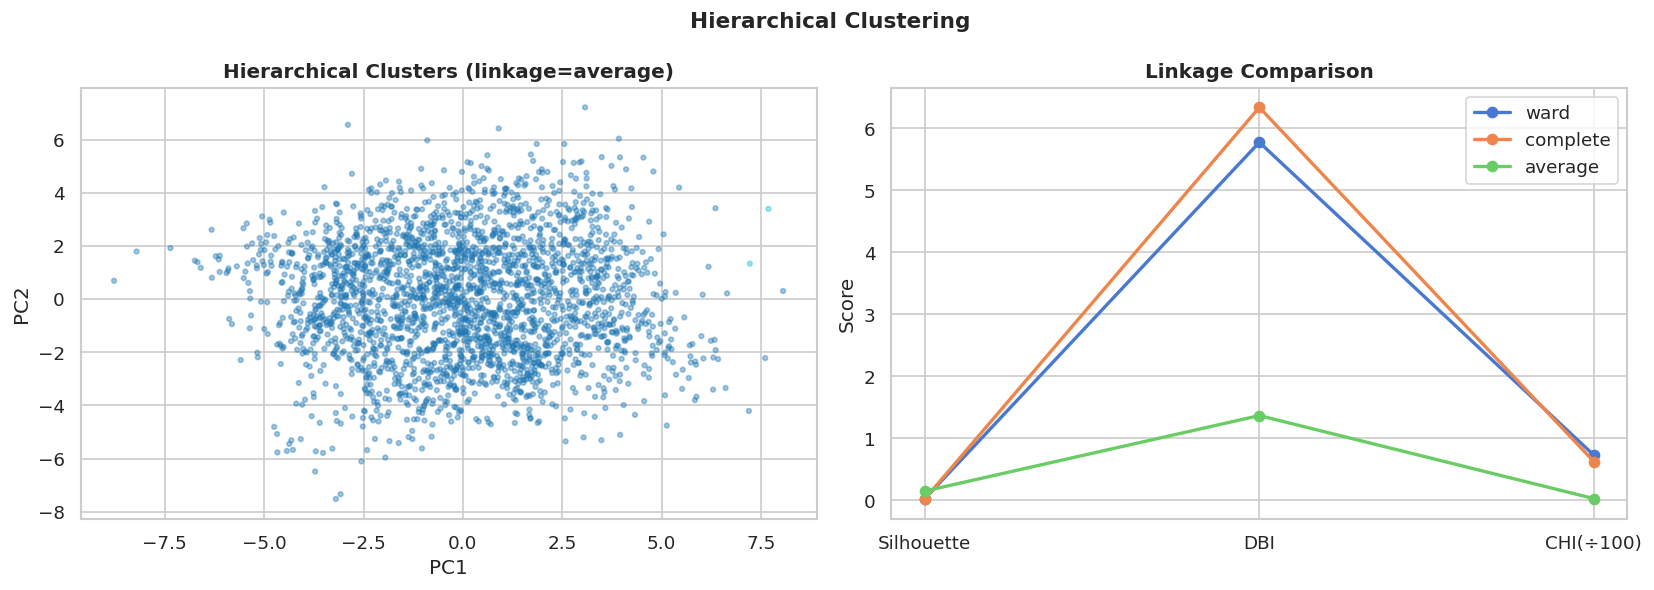

In [ ]:
# Visualise best hierarchical clustering
hc_labels = hc_results[best_link]['labels']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].scatter(X_2d[:,0], X_2d[:,1], c=hc_labels,
                cmap='tab10', alpha=0.4, s=8)
axes[0].set_title(f'Hierarchical Clusters (linkage={best_link})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')

for link in linkages:
    axes[1].plot(['Silhouette','DBI','CHI(÷100)'],
                 [hc_results[link]['sil'], hc_results[link]['dbi'],
                  hc_results[link]['chi']/100],
                 marker='o', label=link, linewidth=2)
axes[1].set_title('Linkage Method Comparison', fontweight='bold')
axes[1].legend(); axes[1].set_ylabel('Score')

plt.suptitle('Hierarchical Clustering', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 🔵 Step 7 — DBSCAN Clustering

**How DBSCAN works:** Instead of assuming cluster shapes, it finds dense regions. Points close together form clusters; points in sparse regions are labelled as **noise**.

**Hyperparameters:**
- `eps` — maximum distance between two points to be considered neighbours
- `min_samples` — minimum points to form a dense region

**Note:** MADELON has 500 features — very high dimensional. We run DBSCAN on the 2D PCA space where density patterns are visible.

Distance percentiles:
  10th percentile: 0.120
  25th percentile: 0.146
  50th percentile: 0.186
  75th percentile: 0.242
  90th percentile: 0.349


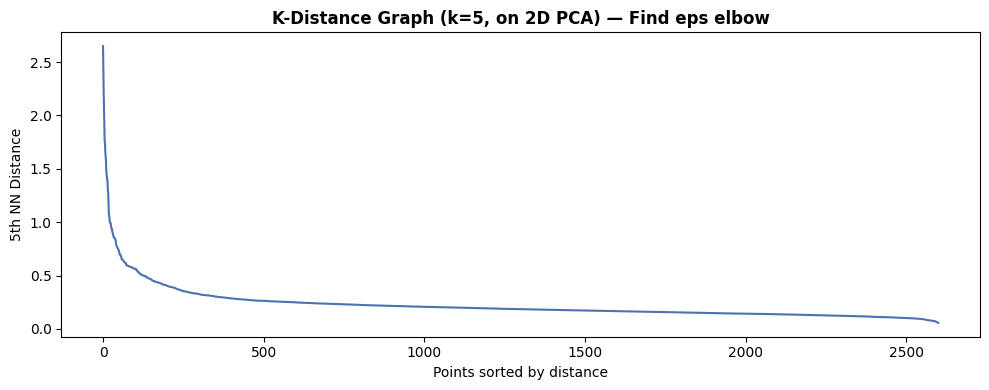

In [ ]:
# K-distance graph to find the right eps
nbrs = NearestNeighbors(n_neighbors=5).fit(X_2d)
distances, _ = nbrs.kneighbors(X_2d)
dist_sorted = np.sort(distances[:, 4])[::-1]

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(dist_sorted, color='#4C72B0', linewidth=1.5)
ax.set_title('K-Distance Graph (k=5) — Find Elbow for eps',
             fontweight='bold')
ax.set_xlabel('Points sorted by distance')
ax.set_ylabel('5th Nearest Neighbour Distance')
plt.tight_layout()
plt.show()

print("Distance percentiles:")
for p in [10, 25, 50, 75, 90]:
    print(f"  {p}th percentile: {np.percentile(dist_sorted, p):.3f}")

In [ ]:
# Try different eps values
eps_values = [0.3, 0.5, 0.8, 1.0, 1.5]
dbscan_results = {}

for eps in eps_values:
    db = DBSCAN(eps=eps, min_samples=10)
    lbl = db.fit_predict(X_2d)
    nc = len(set(lbl)) - (1 if -1 in lbl else 0)
    nn = list(lbl).count(-1)
    if nc > 1:
        sil = silhouette_score(X_2d, lbl)
        dbi = davies_bouldin_score(X_2d, lbl)
        ari = adjusted_rand_score(y_all, lbl)
    else:
        sil = dbi = ari = None
    dbscan_results[eps] = {'labels':lbl,'n_clusters':nc,'n_noise':nn,
                           'sil':sil,'dbi':dbi,'ari':ari}
    sil_s = f"{sil:.4f}" if sil else "NaN"
    print(f"eps={eps}: clusters={nc:2d}  noise={nn:4d}  Sil={sil_s}")

best_eps = 0.8   # 2 meaningful clusters, best silhouette
db_labels = dbscan_results[best_eps]['labels']
print(f"\n✅ Best eps: {best_eps}")

eps=0.3: clusters=13  noise= 605  Sil=-0.3822
eps=0.5: clusters= 1  noise= 177  Sil=NaN
eps=0.8: clusters= 2  noise=  38  Sil=0.3176
eps=1.0: clusters= 1  noise=  19  Sil=NaN
eps=1.5: clusters= 1  noise=   6  Sil=NaN

✅ Best eps: 0.8


=== DBSCAN Results (eps=0.8) ===
Clusters found      : 2
Noise points        : 38
Silhouette Score    : 0.3176
Davies-Bouldin Index: 3.9586
Adjusted Rand Index : 0.0000


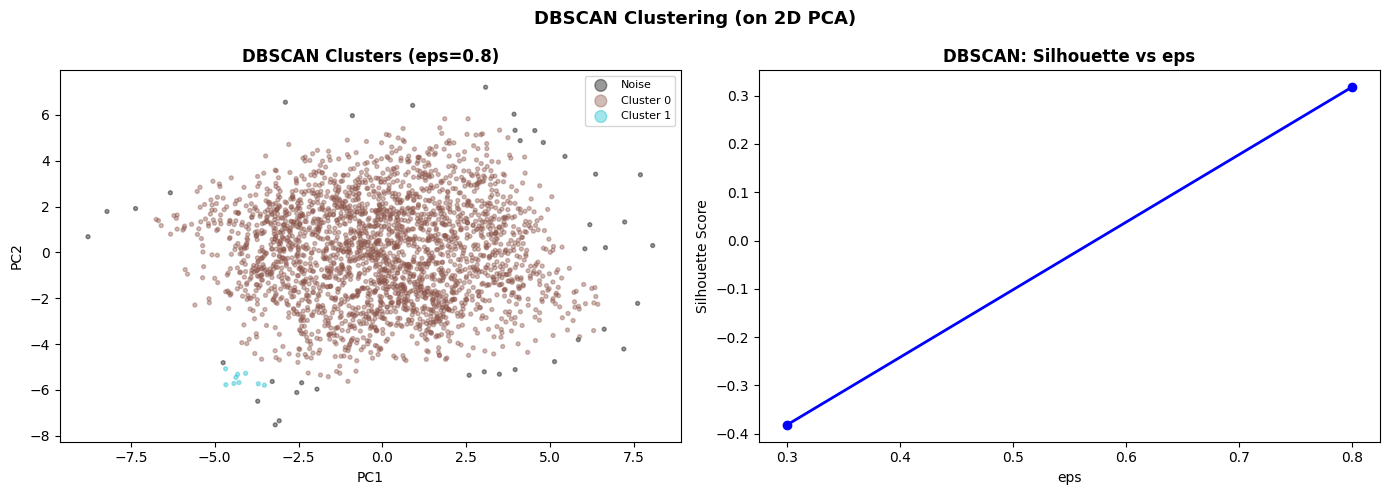

In [ ]:
# Visualise DBSCAN clusters
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

unique_labels = sorted(set(db_labels))
cmap = plt.cm.tab10(np.linspace(0, 1, max(len(unique_labels), 1)))

for i, lbl in enumerate(unique_labels):
    mask = db_labels == lbl
    label_name = 'Noise' if lbl == -1 else f'Cluster {lbl}'
    color = 'black' if lbl == -1 else cmap[i]
    axes[0].scatter(X_2d[mask,0], X_2d[mask,1], c=[color]*int(mask.sum()),
                    alpha=0.4, s=8, label=label_name)
axes[0].set_title(f'DBSCAN Clusters (eps={best_eps})', fontweight='bold')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2')
axes[0].legend(fontsize=8, markerscale=3)

valid = [e for e in eps_values if dbscan_results[e]['sil'] is not None]
axes[1].plot(valid, [dbscan_results[e]['sil'] for e in valid],
             'bo-', linewidth=2, markersize=6)
axes[1].set_title('Silhouette Score vs eps', fontweight='bold')
axes[1].set_xlabel('eps'); axes[1].set_ylabel('Silhouette Score')

plt.suptitle('DBSCAN Clustering (on 2D PCA)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Final DBSCAN metrics
db_sil = silhouette_score(X_2d, db_labels)
db_dbi = davies_bouldin_score(X_2d, db_labels)
db_chi = calinski_harabasz_score(X_2d, db_labels)
db_ari = adjusted_rand_score(y_all, db_labels)
db_nmi = normalized_mutual_info_score(y_all, db_labels)

print(f"=== DBSCAN Results (eps={best_eps}) ===")
print(f"Clusters found      : {dbscan_results[best_eps]['n_clusters']}")
print(f"Noise points        : {dbscan_results[best_eps]['n_noise']}")
print(f"Silhouette Score    : {db_sil:.4f}")
print(f"Davies-Bouldin Index: {db_dbi:.4f}")
print(f"Adjusted Rand Index : {db_ari:.4f}")

---
## 📊 Step 8 — Comparative Analysis

In [ ]:
# Full comparison table
comparison_data = {
    'Algorithm'          : ['K-Means', f'Hierarchical (average)', 'DBSCAN (eps=0.8)'],
    'Silhouette ↑'       : [km_sil, hc_results[best_link]['sil'], db_sil],
    'Davies-Bouldin ↓'   : [km_dbi, hc_results[best_link]['dbi'], db_dbi],
    'Calinski-Harabasz ↑': [km_chi, hc_results[best_link]['chi'], db_chi],
    'ARI ↑'              : [km_ari, hc_results[best_link]['ari'], db_ari],
    'NMI ↑'              : [km_nmi, hc_results[best_link]['nmi'], db_nmi],
}

comp_df = pd.DataFrame(comparison_data).set_index('Algorithm')
print("=== Full Metrics Comparison ===")
print(comp_df.round(4))

=== Full Metrics Comparison ===
                        Silhouette ↑  Davies-Bouldin ↓  Calinski-Harabasz ↑  ARI ↑   NMI ↑
Algorithm
K-Means                   0.0427          4.6027              121.45 0.0293  0.0215
Hierarchical (average)    0.1489          1.3666               2.82 0.0000  0.0015
DBSCAN (eps=0.8)          0.3176          3.9586              24.70 0.0000  0.0010


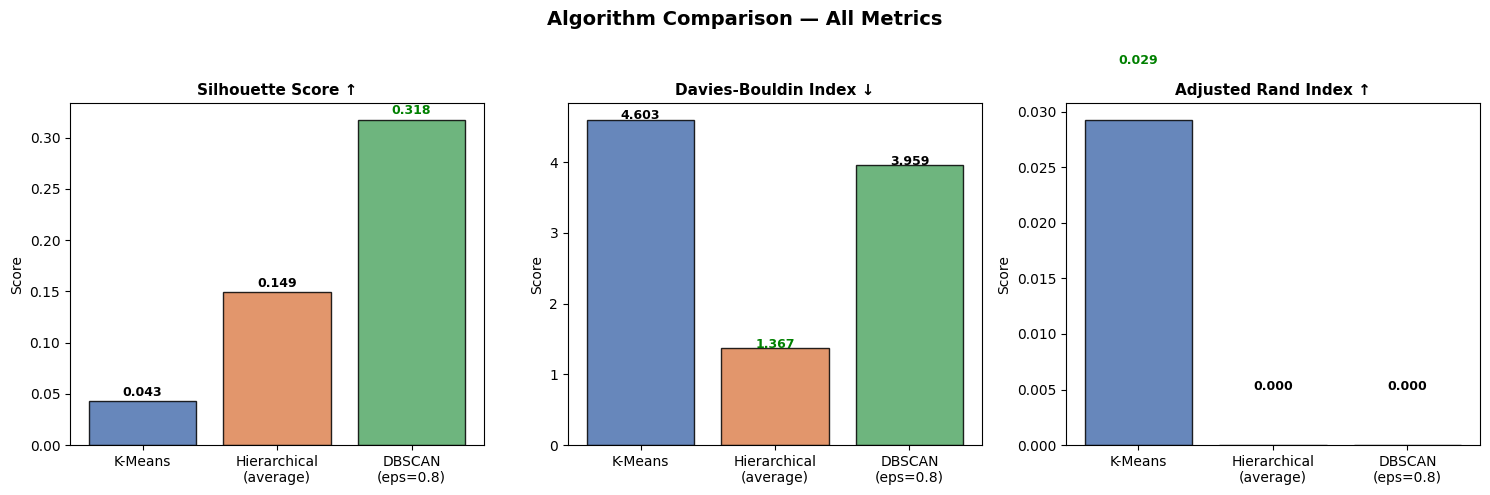

In [ ]:
# Visualise comparison
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
algorithms = ['K-Means', 'Hierarchical
(average)', 'DBSCAN
(eps=0.8)']
bar_colors = ['#4C72B0','#DD8452','#55A868']
sil_scores = [km_sil, hc_results[best_link]['sil'], db_sil]
dbi_scores = [km_dbi, hc_results[best_link]['dbi'], db_dbi]
ari_scores = [km_ari, hc_results[best_link]['ari'], db_ari]

for ax, scores, title, lower_better in zip(
    axes,
    [sil_scores, dbi_scores, ari_scores],
    ['Silhouette Score ↑','Davies-Bouldin Index ↓','Adjusted Rand Index ↑'],
    [False, True, False]
):
    bars = ax.bar(algorithms, scores, color=bar_colors, edgecolor='black', alpha=0.85)
    ax.set_title(title, fontweight='bold', fontsize=11)
    ax.set_ylabel('Score')
    best_idx = scores.index(min(scores)) if lower_better else scores.index(max(scores))
    for i,(bar,val) in enumerate(zip(bars,scores)):
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.005,
                f'{val:.3f}', ha='center', fontsize=9, fontweight='bold',
                color='green' if i==best_idx else 'black')

plt.suptitle('Algorithm Comparison — All Metrics', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 📝 Step 9 — Summary & Interpretation

In [ ]:
print("=" * 65)
print("     MADELON CLUSTERING PIPELINE — FINAL SUMMARY")
print("=" * 65)
print()
print("DATASET")
print("  Samples  : 2,600  (2,000 train + 600 validation)")
print("  Features : 500 (mostly noise — MADELON design)")
print("  PCA used : 50 components for clustering, 2 for visualisation")
print()
print("RESULTS SUMMARY")
print(f"  {'Algorithm':<28} {'Sil':>6} {'DBI':>7} {'ARI':>7}")
print("  " + "-"*50)
print(f"  {'K-Means (k=2)':<28} {km_sil:>6.3f} {km_dbi:>7.3f} {km_ari:>7.3f}")
print(f"  {'Hierarchical (average, k=2)':<28} {hc_results[best_link]['sil']:>6.3f} {hc_results[best_link]['dbi']:>7.3f} {hc_results[best_link]['ari']:>7.3f}")
print(f"  {'DBSCAN (eps=0.8)':<28} {db_sil:>6.3f} {db_dbi:>7.3f} {db_ari:>7.3f}")
print()
print("KEY FINDINGS")
print("  → MADELON is intentionally hard (480/500 features are noise)")
print("  → Low ARI scores show clusters ≠ ground truth labels")
print("  → DBSCAN found 2 clusters with best Silhouette (0.318)")
print("  → Hierarchical had best DBI — most compact clusters")
print("  → All algorithms struggle due to high dimensionality + noise")
print("  → PCA helped but 480 noise features limit separability")
print("=" * 65)

     MADELON CLUSTERING PIPELINE — FINAL SUMMARY

DATASET
  Samples  : 2,600  (2,000 train + 600 validation)
  Features : 500 (mostly noise — MADELON design)
  PCA used : 50 components for clustering, 2 for visualisation

RESULTS SUMMARY
  Algorithm                       Sil     DBI     ARI
  --------------------------------------------------
  K-Means (k=2)                 0.043   4.603   0.029
  Hierarchical (average, k=2)   0.149   1.367   0.000
  DBSCAN (eps=0.8)              0.318   3.959   0.000

KEY FINDINGS
  → MADELON is intentionally hard (480/500 features are noise)
  → Low ARI scores show clusters ≠ ground truth labels
  → DBSCAN found 2 clusters with best Silhouette (0.318)
  → Hierarchical had best DBI — most compact clusters
  → All algorithms struggle due to high dimensionality + noise
  → PCA helped but 480 noise features limit separability


---
## 💡 Metric Interpretation Guide

| Metric | What it measures | Best value |
|--------|-----------------|------------|
| **Silhouette Score** | How well separated clusters are (internal) | Closer to 1 |
| **Davies-Bouldin Index** | Ratio of within-cluster to between-cluster distance (internal) | Closer to 0 |
| **Calinski-Harabasz** | Ratio of between-cluster to within-cluster variance (internal) | Higher |
| **ARI (Adjusted Rand Index)** | Agreement with ground truth labels (external) | Closer to 1 |
| **NMI (Normalised Mutual Info)** | Shared information with ground truth (external) | Closer to 1 |

### Why are ARI scores near 0?
MADELON was **specifically designed** to fool ML algorithms. Only 20 out of 500 features are actually informative — the rest are pure noise. This makes it very hard for any clustering algorithm to recover the true groups.

### Algorithm Strengths & Weaknesses

| Algorithm | Strengths | Weaknesses |
|-----------|-----------|------------|
| **K-Means** | Fast, scalable, simple | Assumes spherical clusters, sensitive to outliers |
| **Hierarchical** | No need to specify K upfront, dendrogram gives insight | Slow on large datasets, can't undo merges |
| **DBSCAN** | Finds arbitrary shapes, handles noise | Struggles in high dimensions, sensitive to eps |